In [2]:
# Clean and Prepare Dataset
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display

# Load dataset
data = pd.read_csv("Depression Student Dataset.csv")

# Drop missing values and duplicates
data_cleaned = data.dropna().drop_duplicates()

# Remove invalid age values
data_cleaned = data_cleaned[data_cleaned['Age'] > 0]

# Standardize 'Sleep Duration'
data_cleaned['Sleep Duration'] = data_cleaned['Sleep Duration'].str.strip().str.lower().replace({
    'less than 5 hours': '<5',
    '5-6 hours': '5-6',
    '7-8 hours': '7-8',
    'more than 8 hours': '>8'
})

# Reintroduce rows with Study Hours == 0
zero_study_rows = data[data['Study Hours'] == 0].copy()
zero_study_rows['Zero_Study_Flag'] = True
data_cleaned['Zero_Study_Flag'] = False

# Combine all rows into final_data
final_data = pd.concat([data_cleaned, zero_study_rows], ignore_index=True)

# Re-clean 'Sleep Duration'
final_data['Sleep Duration'] = final_data['Sleep Duration'].str.strip().str.lower().replace({
    'less than 5 hours': '<5',
    '5-6 hours': '5-6',
    '7-8 hours': '7-8',
    'more than 8 hours': '>8'
})

# Encode Yes/No fields to binary
binary_cols = [
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Depression'
]
for col in binary_cols:
    final_data[col] = final_data[col].map({'Yes': 1, 'No': 0})

# Encode gender
final_data['Gender'] = final_data['Gender'].map({'Male': 0, 'Female': 1})

# Normalize numeric columns (except Age)
scaler = MinMaxScaler()
scale_cols = ['Academic Pressure', 'Study Satisfaction', 'Study Hours', 'Financial Stress']
final_data[scale_cols] = scaler.fit_transform(final_data[scale_cols])

# Add High Stress + Low Satisfaction flag
final_data['High_Stress_Low_Satisfaction'] = (
    (final_data['Academic Pressure'] >= 0.6) &
    (final_data['Study Satisfaction'] <= 0.4)
)

# Display final dataset
print("Final dataset shape:", final_data.shape)
display(final_data.head(10))

Final dataset shape: (536, 13)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression,Zero_Study_Flag,High_Stress_Low_Satisfaction
0,0,28,0.25,0.75,7-8,Moderate,1,0.750000,0.25,1,0,False,False
1,0,28,0.75,1.00,5-6,Healthy,1,0.583333,0.00,1,0,False,False
2,0,25,0.00,0.50,5-6,Unhealthy,1,0.833333,0.75,0,1,False,False
3,0,23,0.00,0.75,>8,Unhealthy,1,0.583333,0.25,1,0,False,False
4,1,31,0.00,1.00,>8,Healthy,1,0.333333,0.25,1,0,False,False
5,0,19,0.75,0.75,5-6,Unhealthy,1,0.083333,0.75,1,1,False,False
6,1,34,0.75,0.25,>8,Moderate,1,0.500000,0.25,0,1,False,True
7,1,20,0.75,0.00,>8,Healthy,1,0.250000,0.75,1,1,False,True
8,1,33,0.00,0.75,>8,Moderate,0,0.833333,0.50,0,0,False,False
9,0,33,0.75,0.50,<5,Unhealthy,1,0.833333,0.00,0,1,False,False


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 3.3 MB/s eta 0:00:00

 Retrieved 40 relevant posts.


,title,score,id,subreddit,url,num_comments,body,created_time
0,Well this sucks,15,1gbjbls,University,https://www.reddit.com/r/University/comments/1...,10,So second year of uni and I fucking hate it. N...,2024-10-25 01:54:20 UTC
1,I’m 23 and wanting to switch degrees — I feel ...,11,1hhpp9u,University,https://www.reddit.com/r/University/comments/1...,37,"For some background info, I am currently in my...",2024-12-19 10:04:19 UTC
2,senior and hate my major,8,1fsktp4,University,https://www.reddit.com/r/University/comments/1...,5,I'm currently regretting all my life choices. ...,2024-09-30 02:05:49 UTC
3,Considering dropping Uni to Join College,8,1hlowde,University,https://www.reddit.com/r/University/comments/1...,21,I currently go to a really prestigious univers...,2024-12-24 23:17:12 UTC
4,Me and my anxiety before university exams,8,1h7xrwh,University,https://www.reddit.com/gallery/1h7xrwh,0,,2024-12-06 09:39:32 UTC



 Top Keywords and Phrases by TF-IDF Score:


,term,score
43,university,5.456320
10,don,5.252826
24,just,4.630439
27,like,4.439908
45,want,4.300154
32,really,4.264957
14,feel,4.045278
48,year,3.894271
25,know,3.834526
6,degree,3.496433


/tmp/ipython-input-3-1463798474.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='term', data=tfidf_df.head(15), palette='viridis')


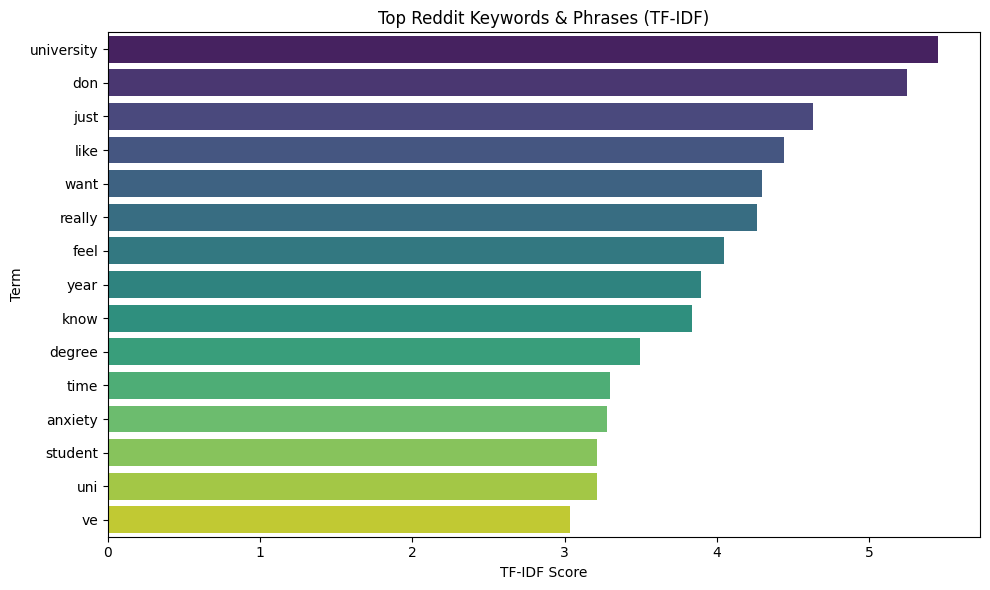

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...



Sentiment Distribution:
sentiment_label
Negative    24
Positive    16
Name: count, dtype: int64


/tmp/ipython-input-3-1463798474.py:174: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reddit_df, x='sentiment_label', palette='pastel')


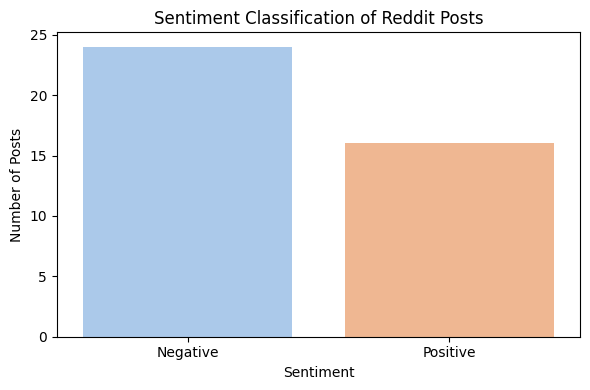

In [3]:
!pip install praw
import praw
from datetime import datetime
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning, module='praw')

# Replace all non-ASCII chars in USER_AGENT
CLIENT_ID = 'zNcQ1NvQzJosv2pT13Ak4w'
CLIENT_SECRET = 'XozYwgolUx6FLZNfEDj04I7CTuSxMg'
USER_AGENT = 'python:TimisoaraDataMiningLab:v1.0 (by /u/No_Grand2711)'

reddit = praw.Reddit(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT,
    check_for_async=False
)

target_subreddit = 'university'
post_limit = 250
fetch_mode = 'top'
time_filter = 'year'

keywords = [
    # Mental health struggles
    'depression', 'suicidal thoughts', 'self harm', 'anxiety', 'burnout',
    'panic attack', 'overwhelmed', 'mental breakdown', 'feeling empty',
    'hopeless', 'crying alone', 'no motivation', 'fatigue', 'tired all the time',
    'sleep deprivation', 'insomnia', 'no energy',

    # Academic stress
    'academic pressure', 'exam stress', 'grades stress', 'study burnout',
    'can\'t focus', 'procrastination', 'performance anxiety', 'finals week',
    'dropout thoughts',

    # Therapy & support
    'therapy', 'i need therapy', 'therapy session', 'counseling center',
    'started therapy', 'mental health support',

    # Financial pressure
    'student debt', 'financial stress', 'rent stress', 'broke college student',
    'can\'t afford food',

    # Doubts about studies
    'wrong major', 'i hate my major', 'switch major', 'don’t enjoy what i study',
    'change my major', 'not passionate about my studies'
]
posts_data = []

try:
    subreddit = reddit.subreddit(target_subreddit)

    if fetch_mode == 'hot':
        post_iterator = subreddit.hot(limit=post_limit)
    elif fetch_mode == 'new':
        post_iterator = subreddit.new(limit=post_limit)
    elif fetch_mode == 'top':
        post_iterator = subreddit.top(time_filter=time_filter, limit=post_limit)
    elif fetch_mode == 'controversial':
        post_iterator = subreddit.controversial(time_filter=time_filter, limit=post_limit)
    else:
        post_iterator = subreddit.hot(limit=post_limit)

    for post in post_iterator:
        try:
            title = post.title.encode('utf-8', errors='ignore').decode('utf-8')
            body = post.selftext.encode('utf-8', errors='ignore').decode('utf-8')

            if any(k in title.lower() or k in body.lower() for k in keywords):
                posts_data.append({
                    'title': title,
                    'score': post.score,
                    'id': post.id,
                    'subreddit': post.subreddit.display_name,
                    'url': post.url,
                    'num_comments': post.num_comments,
                    'body': body,
                    'created_time': datetime.utcfromtimestamp(post.created_utc).strftime('%Y-%m-%d %H:%M:%S UTC')
                })
        except:
            continue

    reddit_df = pd.DataFrame(posts_data)
    print(f"\n Retrieved {len(reddit_df)} relevant posts.")
    from IPython.display import display
    display(reddit_df.head())

except Exception as e:
    print("\n Fatal error while fetching posts.")
    print(f"Reason: {str(e)}")

# TF-IDF & N-gram Keyword Analysis on Reddit Posts

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Combine title and body to form a single text field per post
reddit_df['full_text'] = reddit_df['title'] + " " + reddit_df['body']

# Basic preprocessing: remove empty posts
reddit_df = reddit_df[reddit_df['full_text'].str.strip().astype(bool)]

# Create TF-IDF vectorizer (unigrams + bigrams)
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),       # Unigrams + Bigrams
    max_features=50           # Keep top 50 by TF-IDF score
)

# Fit the model on the full text
tfidf_matrix = vectorizer.fit_transform(reddit_df['full_text'])

# Extract feature names and scores
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.sum(axis=0).A1  # total tf-idf score per term

# Combine into a DataFrame for easy plotting
tfidf_df = pd.DataFrame({
    'term': feature_names,
    'score': tfidf_scores
}).sort_values(by='score', ascending=False)

# Show top terms
print("\n Top Keywords and Phrases by TF-IDF Score:")
display(tfidf_df.head(15))

# Optional: Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='score', y='term', data=tfidf_df.head(15), palette='viridis')
plt.title('Top Reddit Keywords & Phrases (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Term')
plt.tight_layout()
plt.show()

# Sentiment Analysis on Reddit Posts

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download necessary lexicons
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment scoring to each post
reddit_df['sentiment_scores'] = reddit_df['full_text'].apply(sia.polarity_scores)

# Extract compound score into its own column
reddit_df['sentiment_compound'] = reddit_df['sentiment_scores'].apply(lambda score_dict: score_dict['compound'])

# Classify sentiment as Positive / Neutral / Negative
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reddit_df['sentiment_label'] = reddit_df['sentiment_compound'].apply(classify_sentiment)

# Show sentiment breakdown
sentiment_counts = reddit_df['sentiment_label'].value_counts()
print("\nSentiment Distribution:")
print(sentiment_counts)

# Plot sentiment distribution
plt.figure(figsize=(6,4))
sns.countplot(data=reddit_df, x='sentiment_label', palette='pastel')
plt.title('Sentiment Classification of Reddit Posts')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()



In [4]:
# Topic Modeling with LDA (Improved Version)

import re
import string
import pandas as pd
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Function to clean text

def basic_clean(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # Remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))  # Remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
    return text


# Apply cleaning function to Reddit dataset
reddit_df['clean_text'] = reddit_df['full_text'].apply(basic_clean)


# Define stopwords (default English + domain-specific)

custom_stopwords = list(text.ENGLISH_STOP_WORDS.union([
    'just', 'like', 'know', 'im', 'dont', 'really', 'going', 'got',
    'thing', 'feel', 'time', 'people', 'make', 'want', 'one', 'even', 'would'
]))


# Convert cleaned text into Document-Term Matrix (DTM)
vectorizer = CountVectorizer(
    max_df=0.85,         # Exclude terms in >85% of documents (too frequent)
    min_df=2,            # Exclude rare terms (appear in <2 docs)
    stop_words=custom_stopwords,
    ngram_range=(1, 2)   # Include unigrams and bigrams
)
dtm = vectorizer.fit_transform(reddit_df['clean_text'])  # Apply transformation
feature_names = vectorizer.get_feature_names_out()       # Vocabulary

# Train Latent Dirichlet Allocation (LDA) model

lda_model = LatentDirichletAllocation(
    n_components=3,       # Number of topics
    random_state=42,
    learning_method='online',
    max_iter=20
)
lda_model.fit(dtm)


# Display top words for each topic

def print_topics(model, feature_names, n_words=10):
    print("\n Top words per topic:")
    for idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_words - 1:-1]]
        print(f"Topic {idx + 1}: {' | '.join(top_features)}")

print_topics(lda_model, feature_names)


 Top words per topic:
Topic 1: don | year | semester | exams | burnout | reason | better | life | degree | study
Topic 2: uni | anxiety | presentation | don | university | students | work | ve | student | lack
Topic 3: university | year | life | school | years | degree | study | ve | wanted | think


/tmp/ipython-input-5-3036866526.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=student_df, x="depression", palette="pastel")


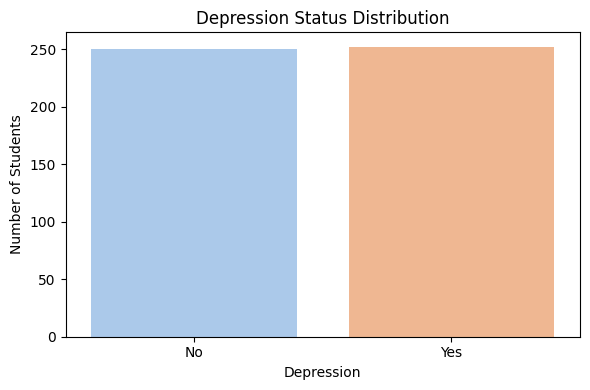

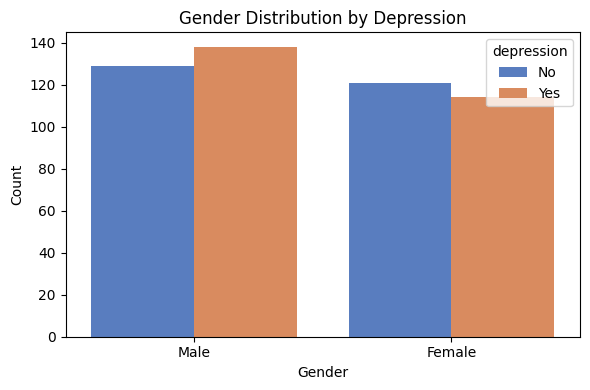

/tmp/ipython-input-5-3036866526.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_df, x="depression", y="financial_stress", palette="Set2")


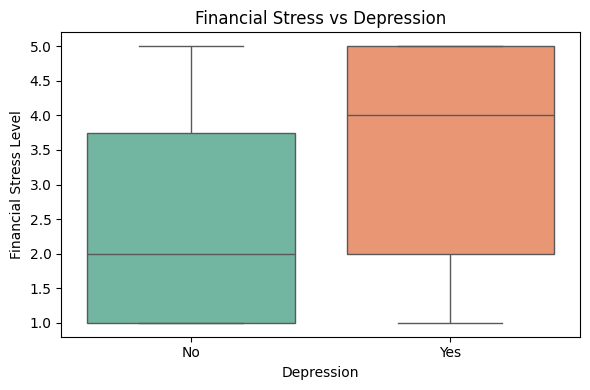

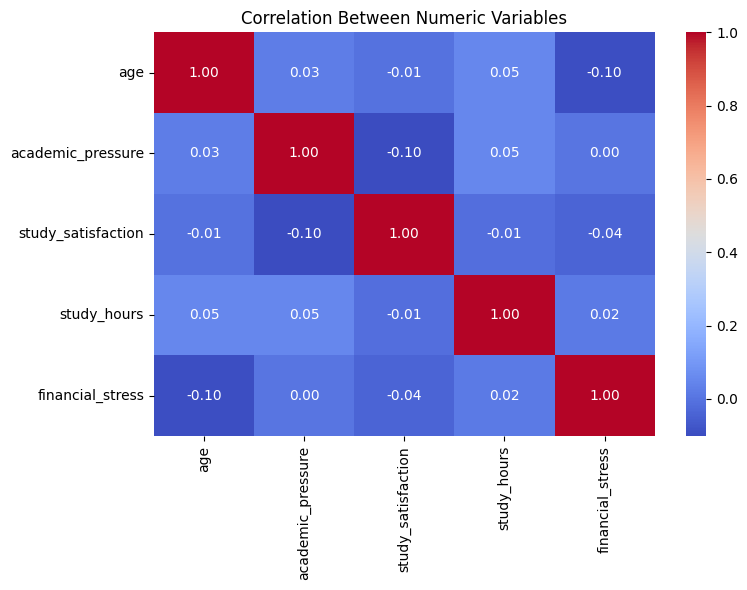


 Reddit Avg Sentiment Score: -0.10
Sentiment Breakdown:
sentiment_label
Negative    24
Positive    16
Name: count, dtype: int64


/tmp/ipython-input-5-3036866526.py:69: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




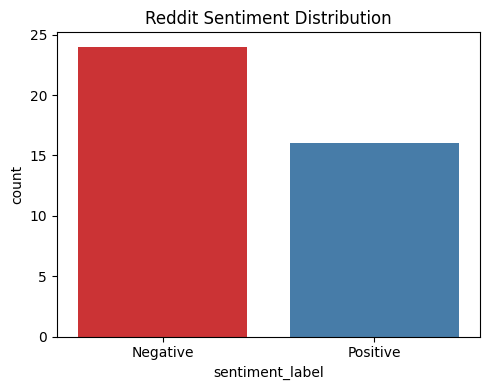

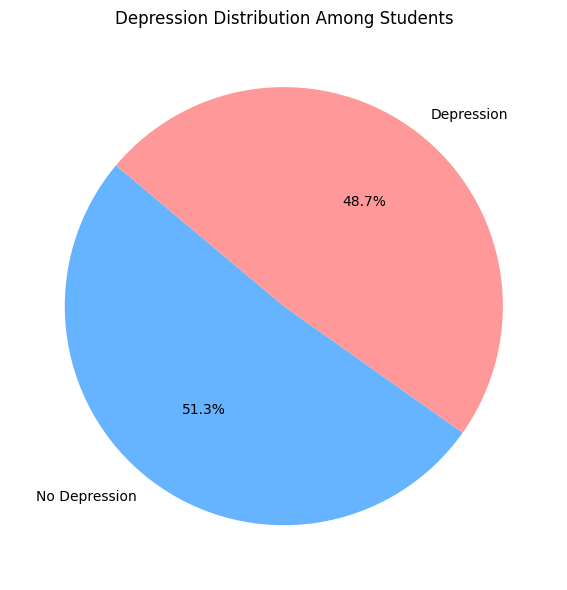

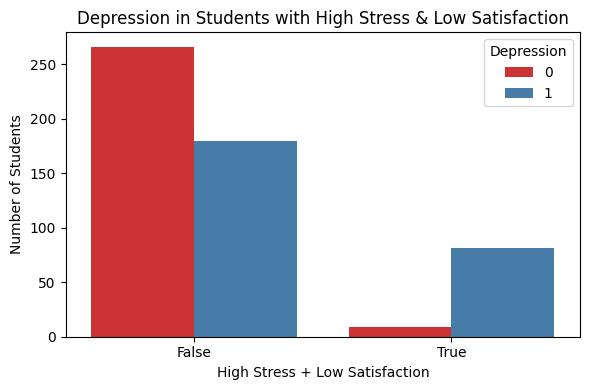

Students at-risk group with depression: 70.0%


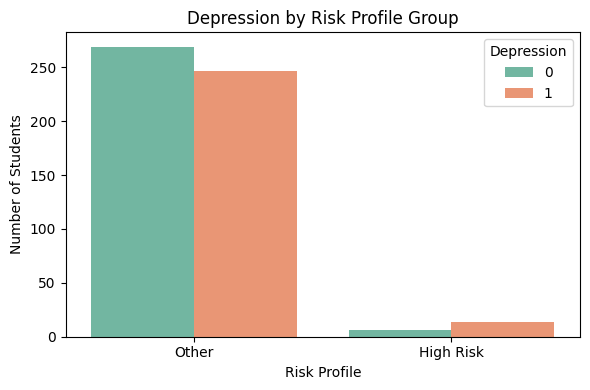

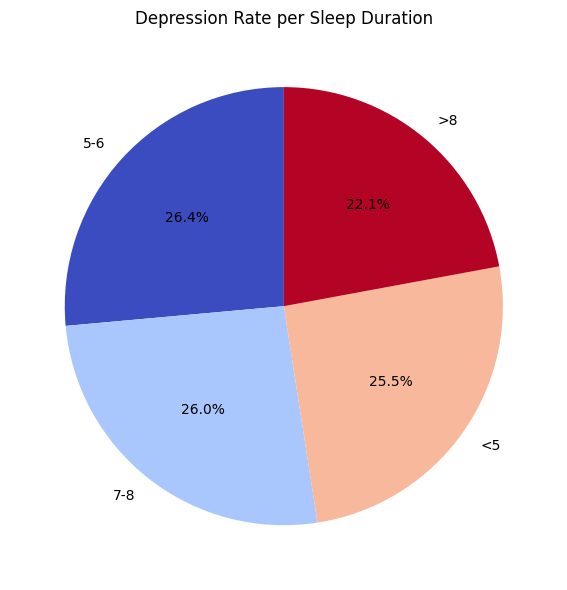

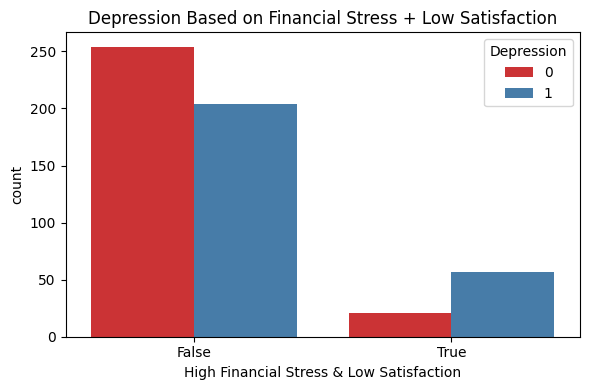

In [5]:
# EDA & Data Visualization
# Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load Cleaned Dataset
student_df = pd.read_csv("Depression Student Dataset.csv")

# Clean column names
student_df.columns = student_df.columns.str.strip().str.replace(" ", "_").str.lower()
student_df.rename(columns={
    "have_you_ever_had_suicidal_thoughts_?": "suicidal_thoughts",
    "family_history_of_mental_illness": "family_history"
}, inplace=True)

# Univariate: Depression
plt.figure(figsize=(6, 4))
sns.countplot(data=student_df, x="depression", palette="pastel")
plt.title("Depression Status Distribution")
plt.xlabel("Depression")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

# Gender vs Depression
plt.figure(figsize=(6, 4))
sns.countplot(data=student_df, x="gender", hue="depression", palette="muted")
plt.title("Gender Distribution by Depression")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Financial Stress & Depression
plt.figure(figsize=(6, 4))
sns.boxplot(data=student_df, x="depression", y="financial_stress", palette="Set2")
plt.title("Financial Stress vs Depression")
plt.xlabel("Depression")
plt.ylabel("Financial Stress Level")
plt.tight_layout()
plt.show()

# Sleep Duration Treemap
if "sleep_duration" in student_df.columns:
    sleep_dist = student_df["sleep_duration"].value_counts().reset_index()
    sleep_dist.columns = ["sleep_duration", "count"]
    fig = px.treemap(sleep_dist, path=["sleep_duration"], values="count",
                     title="Sleep Duration Distribution", color_discrete_sequence=px.colors.sequential.RdBu)
    fig.show()

# Correlation Heatmap
numeric_df = student_df.select_dtypes(include=["int64", "float64"])
if not numeric_df.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Between Numeric Variables")
    plt.tight_layout()
    plt.show()

# Optional: Reddit Sentiment Comparison
if 'reddit_df' in globals() and not reddit_df.empty:
    avg_sentiment = reddit_df['sentiment_compound'].mean()
    print(f"\n Reddit Avg Sentiment Score: {avg_sentiment:.2f}")
    sentiment_counts = reddit_df['sentiment_label'].value_counts()
    print(f"Sentiment Breakdown:\n{sentiment_counts}")

    plt.figure(figsize=(5, 4))
    sns.countplot(data=reddit_df, x='sentiment_label', palette='Set1')
    plt.title("Reddit Sentiment Distribution")
    plt.tight_layout()
    plt.show()

# Binning values for visualization
final_data['hours_bin'] = (final_data['Study Hours'] * 10).round(0) / 10
final_data['satisfaction_bin'] = (final_data['Study Satisfaction'] * 10).round(0) / 10


#Compute depression frequencies
depression_counts = final_data['Depression'].value_counts()
labels = ['No Depression', 'Depression']
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(6, 6))
plt.pie(depression_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Depression Distribution Among Students')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=final_data, x="High_Stress_Low_Satisfaction", hue="Depression", palette="Set1")
plt.title("Depression in Students with High Stress & Low Satisfaction")
plt.xlabel("High Stress + Low Satisfaction")
plt.ylabel("Number of Students")
plt.xticks([0, 1], ["False", "True"])
plt.tight_layout()
plt.show()


# Identify students with very high stress, low satisfaction, and few study hours
at_risk = final_data[
    (final_data['Academic Pressure'] > 0.7) &
    (final_data['Study Satisfaction'] < 0.3) &
    (final_data['Study Hours'] < 0.2)
]

risk_ratio = (len(at_risk[at_risk['Depression'] == 1]) / len(at_risk)) * 100

print(f"Students at-risk group with depression: {risk_ratio:.1f}%")

# Barplot comparing depression rates inside vs outside the high-risk profile
final_data['Risk Profile'] = 'Other'
final_data.loc[at_risk.index, 'Risk Profile'] = 'High Risk'

plt.figure(figsize=(6, 4))
sns.countplot(data=final_data, x='Risk Profile', hue='Depression', palette='Set2')
plt.title("Depression by Risk Profile Group")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

# Create a pie chart of depression rates per sleep duration
sleep_depression = final_data.groupby('Sleep Duration')['Depression'].mean().sort_index()

plt.figure(figsize=(6, 6))
sleep_depression.plot(kind='pie', autopct='%1.1f%%', startangle=90, colormap='coolwarm')
plt.title("Depression Rate per Sleep Duration")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Combine two key factors: High financial stress and low satisfaction
final_data['Stress+Satisfaction Risk'] = (
    (final_data['Financial Stress'] > 0.6) & (final_data['Study Satisfaction'] < 0.4)
)

plt.figure(figsize=(6, 4))
sns.countplot(data=final_data, x="Stress+Satisfaction Risk", hue="Depression", palette="Set1")
plt.title("Depression Based on Financial Stress + Low Satisfaction")
plt.xlabel("High Financial Stress & Low Satisfaction")
plt.xticks([0, 1], ["False", "True"])
plt.tight_layout()
plt.show()

Average Study Hours by Depression Status:
Depression
0    0.428182
1    0.575351
Name: Study Hours, dtype: float64


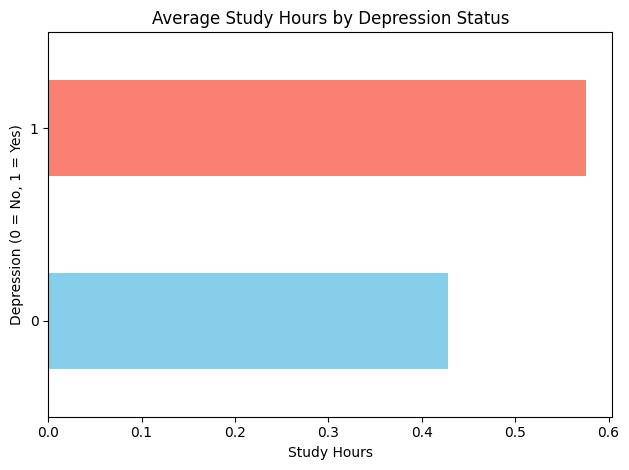


T-test p-value: 0.0000
The difference is statistically significant.

Insight:
Despite the general assumption that students with depression study less,
our data shows the opposite: they studied SLIGHTLY more on average.
This may reflect performance anxiety, perfectionism, or feelings of guilt.



In [20]:
# Analysis of Depression and Study Hours Relationship
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Compute mean study hours for each depression group
avg_study_by_depression = final_data.groupby("Depression")["Study Hours"].mean()

print("Average Study Hours by Depression Status:")
print(avg_study_by_depression)

# Horizontal barplot
avg_study_by_depression.plot(kind='barh', color=['skyblue', 'salmon'])
plt.title("Average Study Hours by Depression Status")
plt.xlabel("Study Hours")
plt.ylabel("Depression (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

# Statistical test: T-test for mean difference
group_no = final_data[final_data['Depression'] == 0]['Study Hours']
group_yes = final_data[final_data['Depression'] == 1]['Study Hours']

t_stat, p_value = ttest_ind(group_no, group_yes)
print(f"\nT-test p-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("The difference is statistically significant.")
else:
    print("The difference is NOT statistically significant.")

# Insight for presentation
print("""
Insight:
Despite the general assumption that students with depression study less,
our data shows the opposite: they studied SLIGHTLY more on average.
This may reflect performance anxiety, perfectionism, or feelings of guilt.
""")


Logistic Regression Accuracy: 96.30%

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        49
           1       0.97      0.97      0.97        59

    accuracy                           0.96       108
   macro avg       0.96      0.96      0.96       108
weighted avg       0.96      0.96      0.96       108



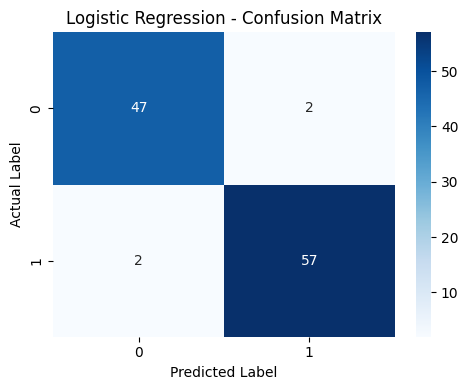

/tmp/ipython-input-21-1753766205.py:84: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




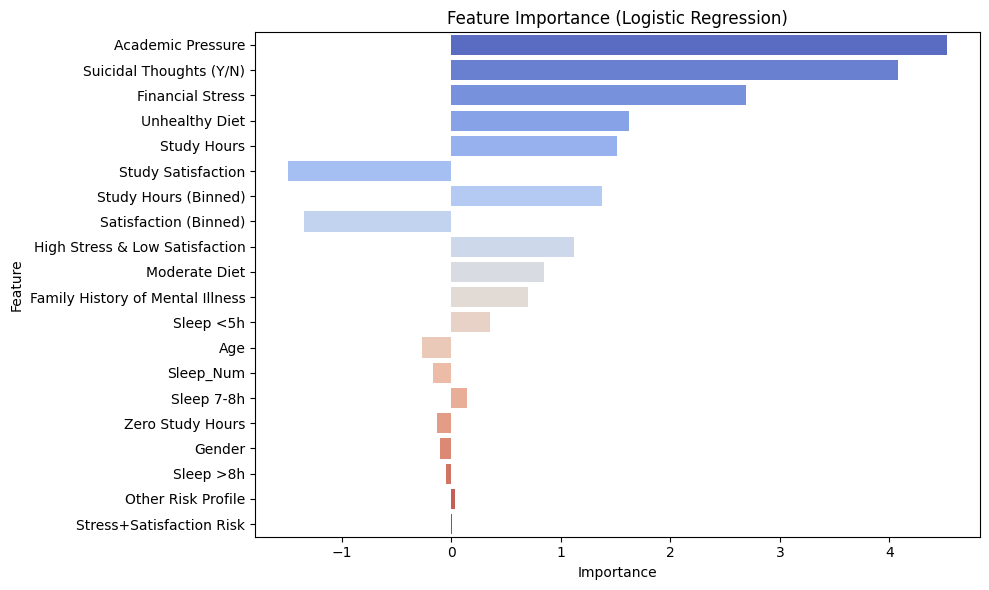

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Model Preparation
model_df = final_data.copy()

# Identify categorical columns (excluding 'Depression')
object_cols = model_df.select_dtypes(include='object').columns.tolist()
object_cols = [col for col in object_cols if col != 'Depression']

# One-hot encode categorical variables
model_df = pd.get_dummies(model_df, columns=object_cols, drop_first=True)

# Drop any remaining missing values
model_df.dropna(inplace=True)

# Define features (X) and target (y)
X = model_df.drop(columns=['Depression'])
y = model_df['Depression']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Model accuracy and report
acc_lr = accuracy_score(y_test, y_pred_lr) * 100
print(f"\nLogistic Regression Accuracy: {acc_lr:.2f}%")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Feature Importance (Coefficients)
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr.coef_[0]
}).sort_values(by='Importance', key=abs, ascending=False)

# Clean feature names for readability
nice_names = {
    'Academic Pressure': 'Academic Pressure',
    'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts (Y/N)',
    'Financial Stress': 'Financial Stress',
    'Dietary Habits_Unhealthy': 'Unhealthy Diet',
    'Dietary Habits_Moderate': 'Moderate Diet',
    'Study Hours': 'Study Hours',
    'Study Satisfaction': 'Study Satisfaction',
    'hours_bin': 'Study Hours (Binned)',
    'satisfaction_bin': 'Satisfaction (Binned)',
    'High_Stress_Low_Satisfaction': 'High Stress & Low Satisfaction',
    'Family History of Mental Illness': 'Family History of Mental Illness',
    'Sleep Duration_<5': 'Sleep <5h',
    'Sleep Duration_5-6': 'Sleep 5-6h',
    'Sleep Duration_7-8': 'Sleep 7-8h',
    'Sleep Duration_>8': 'Sleep >8h',
    'Zero_Study_Flag': 'Zero Study Hours',
    'Gender': 'Gender',
    'Age': 'Age',
    'Risk Profile_Other': 'Other Risk Profile',
    'Stress+Satisfaction Risk': 'Stress+Satisfaction Risk'
}

feature_importance_lr['Feature'] = feature_importance_lr['Feature'].replace(nice_names)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_lr,
    palette='coolwarm'
)
plt.title("Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.show()


Random Forest Accuracy: 90.74%

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        49
           1       0.92      0.92      0.92        59

    accuracy                           0.91       108
   macro avg       0.91      0.91      0.91       108
weighted avg       0.91      0.91      0.91       108



/tmp/ipython-input-11-203100789.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




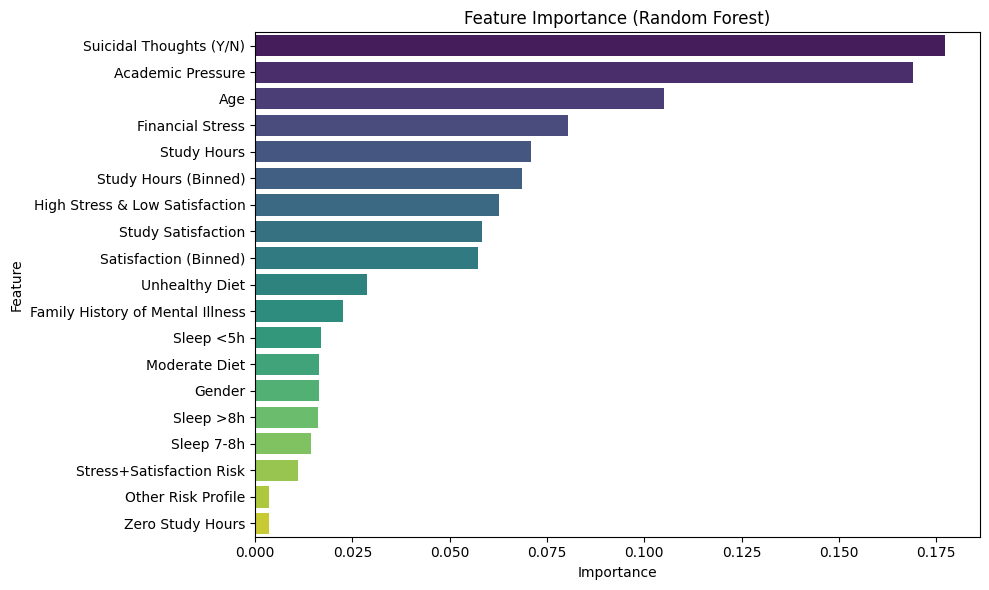

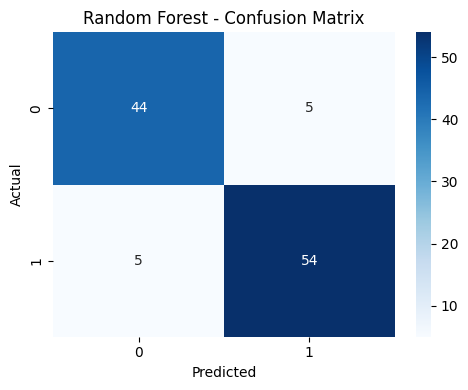

In [11]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f"\nRandom Forest Accuracy: {acc_rf:.2f}%")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Feature Importance (trees-based)
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance_rf['Feature'] = feature_importance_rf['Feature'].replace(nice_names)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf, palette='viridis')
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [22]:
# Compute predicted probabilities
y_proba = lr.predict_proba(X_test)[:, 1]

# Find index of the highest risk student
most_at_risk_idx = y_proba.argmax()

# Retrieve the feature values of this student
most_at_risk_profile = X_test.iloc[most_at_risk_idx]

print("Profile of the student with the highest predicted depression risk:\n")
pd.set_option('display.max_rows', None)
display(most_at_risk_profile.to_frame(name="Value"))

Profile of the student with the highest predicted depression risk:



,Value
Gender,0
Age,22
Academic Pressure,1.0
Study Satisfaction,0.25
Have you ever had suicidal thoughts ?,1
Study Hours,1.0
Financial Stress,0.75
Family History of Mental Illness,0
Zero_Study_Flag,False
High_Stress_Low_Satisfaction,True


Number of high-satisfaction students flagged as high-risk (>0.75 probability): 53


,Predicted_Prob,Academic_Pressure,Study_Satisfaction
5,0.991537,0.75,0.75
10,0.812461,1.00,0.75
12,0.945727,1.00,1.00
18,0.988721,1.00,1.00
63,0.959480,0.25,0.75


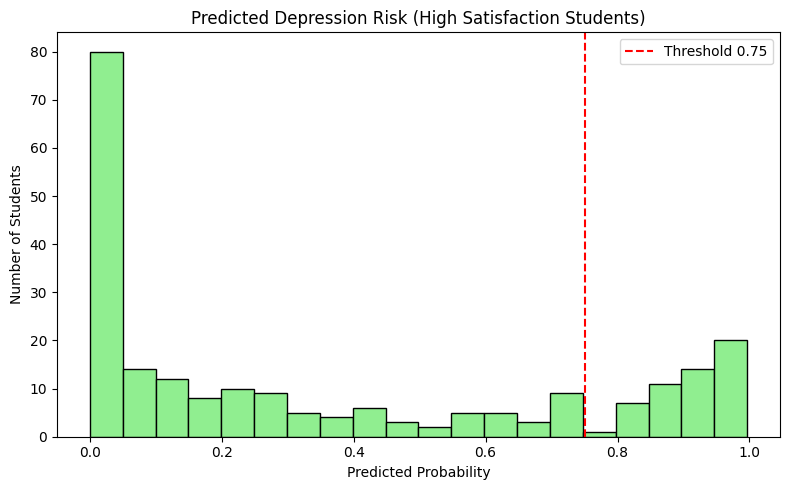

In [27]:
# Compute predicted probabilities on all data
y_proba_all = lr.predict_proba(X)[:, 1]
model_df['Predicted_Prob'] = y_proba_all

# Re-attach satisfaction and stress for interpretation
model_df['Study_Satisfaction'] = final_data['Study Satisfaction']
model_df['Academic_Pressure'] = final_data['Academic Pressure']

# Filter: High satisfaction
high_satisfaction_df = model_df[model_df['Study_Satisfaction'] > 0.6]

# Define an absolute threshold
threshold = 0.75
masked_risk = high_satisfaction_df[high_satisfaction_df['Predicted_Prob'] >= threshold]

print(f"Number of high-satisfaction students flagged as high-risk (>0.75 probability): {len(masked_risk)}")

# Optional preview
display(masked_risk[['Predicted_Prob', 'Academic_Pressure', 'Study_Satisfaction']].head())

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(high_satisfaction_df['Predicted_Prob'], bins=20, color='lightgreen', edgecolor='k')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold 0.75')
plt.title("Predicted Depression Risk (High Satisfaction Students)")
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-24-3658165816.py:34: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



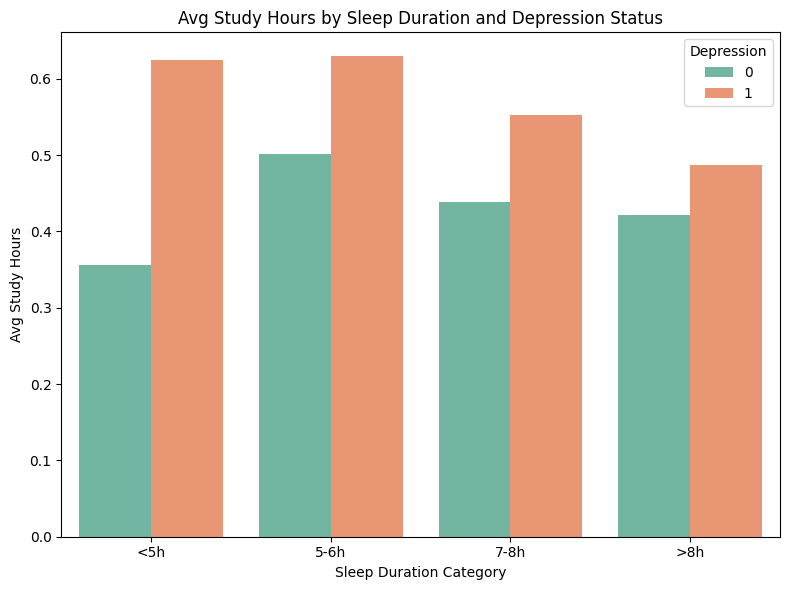

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy the dataset
df = final_data.copy()

# Convert Sleep Duration to numeric hours
def parse_sleep(x):
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('<'):
            return 4.5
        elif x.startswith('>'):
            return 9
        elif '-' in x:
            parts = x.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        else:
            return float(x)
    return x

df['Sleep_Hours_Num'] = df['Sleep Duration'].apply(parse_sleep)

# Create sleep duration categories
sleep_bins = pd.cut(
    df['Sleep_Hours_Num'],
    bins=[0,5,6,8,24],
    labels=['<5h','5-6h','7-8h','>8h']
)
df['Sleep_Num'] = sleep_bins

# Compute average study hours per Sleep Duration and Depression status
grouped = df.groupby(['Sleep_Num', 'Depression'])['Study Hours'].mean().reset_index()

# Bar Plot: Avg Study Hours by Sleep Duration and Depression
plt.figure(figsize=(8,6))
sns.barplot(
    data=grouped,
    x='Sleep_Num',
    y='Study Hours',
    hue='Depression',
    palette='Set2'
)
plt.title("Avg Study Hours by Sleep Duration and Depression Status")
plt.xlabel("Sleep Duration Category")
plt.ylabel("Avg Study Hours")
plt.legend(title="Depression")
plt.tight_layout()
plt.show()